In [131]:
import pandas as pd 
import numpy as np 
import sklearn as sk
import seaborn as sns
import os 
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"

In [132]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
train_id=['CRC1502','CRC1620','CRC1139']
tratt_cercato=['cetux','CTX72h']
train=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in train_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        train=pd.concat([train,data])

filtered_annotated_saver_ribomito_CRC1502_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1139_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1620_cetux_1_log2_pc1_cpm.csv


In [133]:
from func_NT_cetux import *
df=train
df_clean, dup = strip_prefix_from_genes(df, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")
hvg=pd.read_csv('bbknn_cetux_KRAS/highly_variable_genes.csv',header=0,index_col=False)
to_keep=list(hvg['gene'])
to_keep = to_keep + ['sample', 'cell_id', 'trattamento']
df_clean = df_clean.loc[:,to_keep]
clu_path='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv'
meta_data=pd.read_csv(clu_path,header=0)
df_clean['uid']=df_clean['sample']+df_clean['trattamento']+'|'+df_clean['cell_id']+'|'+df_clean['trattamento']
label=meta_data.loc[:,['uid','leiden_r0.3']]
label=label.rename(columns={'leiden_r0.3':'cluster'})
merged_df = df_clean.merge(label, on='uid', how='inner')
meta_cols = ['uid','sample','cell_id','trattamento','cluster']
feature_cols = [c for c in merged_df.columns if c not in meta_cols]

In [134]:
X = merged_df[feature_cols].copy()
y = merged_df['cluster'].copy()


X.index = merged_df['uid']
y.index = merged_df['uid']


groups = merged_df.set_index('uid')['sample']  
use_group_split = False  # metti True se vuoi split per sample

if use_group_split:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
else:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

In [135]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

meta_cols = ['uid','sample','cell_id','trattamento','cluster']
feature_cols = [c for c in merged_df.columns if c not in meta_cols]

X = merged_df[feature_cols].copy()
y = merged_df['cluster'].copy()
samples = merged_df['sample'].copy()

# indicizza tutto per uid (comodo per .loc)
X.index = merged_df['uid'].values
y.index = merged_df['uid'].values
samples.index = merged_df['uid'].values

print("KRAS+cetux cells:", X.shape[0], "features:", X.shape[1])
print("Samples:", samples.unique())
print("Cluster counts:\n", y.value_counts().sort_index())

KRAS+cetux cells: 12947 features: 1500
Samples: ['CRC1502' 'CRC1139' 'CRC1620']
Cluster counts:
 cluster
0    2988
1    2450
2    1995
3    1886
4    1701
5    1406
6     521
Name: count, dtype: int64


In [136]:
def margin_score(probs: np.ndarray) -> np.ndarray:
    p_sorted = np.sort(probs, axis=1)
    return p_sorted[:, -1] - p_sorted[:, -2]

def pick_tau_for_risk(scores: np.ndarray, err: np.ndarray,
                      risk_target: float = 0.05,
                      min_coverage: float = 0.2):
    taus = np.unique(scores)[::-1]
    best_tau, best_cov = None, -1.0
    for t in taus:
        m = scores >= t
        if m.sum() == 0:
            continue
        cov = m.mean()
        if cov < min_coverage:
            continue
        risk = err[m].mean()
        if risk <= risk_target and cov > best_cov:
            best_tau, best_cov = float(t), float(cov)
    return best_tau, best_cov


In [137]:
rf_params = dict(
    random_state=42,
    n_jobs=3,
    max_depth=None,
    max_features='log2',
    min_samples_split=2,
    n_estimators=300
)

unique_samples = samples.unique()

taus = []
fold_summary = []
cell_level = [] 
def entropy(probs, eps=1e-12):
    p = np.clip(probs, eps, 1.0)
    return -(p * np.log(p)).sum(axis=1)

for holdout in unique_samples:
    tr_idx = samples != holdout
    va_idx = samples == holdout

    X_tr, y_tr = X.loc[tr_idx], y.loc[tr_idx]
    X_va, y_va = X.loc[va_idx], y.loc[va_idx]

    scaler = MaxAbsScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_tr_s, y_tr)

    probs_va = rf.predict_proba(X_va_s)
    pred_va = probs_va.argmax(axis=1)

    scores_va = margin_score(probs_va)
    err_va = (pred_va != y_va.values).astype(int)

    tau, cov = pick_tau_for_risk(scores_va, err_va, risk_target=0.05, min_coverage=0.2)

    if tau is None:

        tau = float(np.quantile(scores_va, 0.30))
        cov = float((scores_va >= tau).mean())

    risk = float(err_va[scores_va >= tau].mean())

    taus.append(tau)
    fold_summary.append((holdout, tau, cov, risk))

    print(f"Holdout {holdout}: tau={tau:.4f}, coverage={cov:.3f}, risk={risk:.3f}")
    probs_va = rf.predict_proba(X_va_s)
    pred_va = probs_va.argmax(axis=1)

    scores_va = margin_score(probs_va)   # margin
    maxp_va = probs_va.max(axis=1)
    H_va = entropy(probs_va)
    Hn_va = H_va / np.log(probs_va.shape[1])

    err_va = (pred_va != y_va.values).astype(int)

    # tau, cov = pick_tau_for_risk(scores_va, err_va, risk_target=0.01, min_coverage=0.2)
    # if tau is None:
    #     tau = float(np.quantile(scores_va, 0.30))

    accepted_va = scores_va >= tau
    correct_va = pred_va == y_va.values

    # salva per-cellula SOLO del holdout sample
    tmp = pd.DataFrame({
        "uid": X_va.index,
        "holdout": holdout,
        "y_true": y_va.values,
        "y_pred": pred_va,
        "margin": scores_va,
        "max_prob": maxp_va,
        "H_norm": Hn_va,
        "accepted": accepted_va,
        "correct": correct_va
    }).set_index("uid")

    cell_level.append(tmp)
    
df_cells = pd.concat(cell_level, axis=0)
df_cells.head()

tau_final = float(np.median(taus))
print("\nFinal tau (median across folds):", tau_final)
df_folds = pd.DataFrame(fold_summary, columns=["holdout","tau","coverage","risk"])
df_folds = df_folds.sort_values("holdout")

tau_med = np.median(df_folds["tau"])
print(df_folds)
print("tau_med:", tau_med)

Holdout CRC1502: tau=0.0767, coverage=0.853, risk=0.049
Holdout CRC1139: tau=0.1133, coverage=0.756, risk=0.049
Holdout CRC1620: tau=0.0567, coverage=0.898, risk=0.049

Final tau (median across folds): 0.07666666666666669
   holdout       tau  coverage      risk
1  CRC1139  0.113333  0.756198  0.049180
0  CRC1502  0.076667  0.852924  0.048824
2  CRC1620  0.056667  0.897922  0.049330
tau_med: 0.07666666666666669


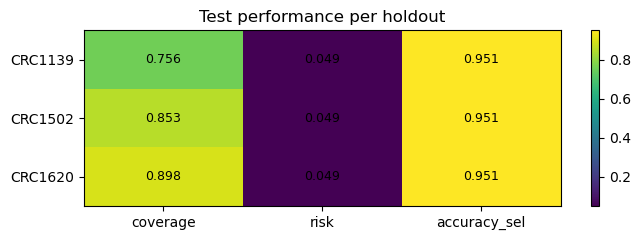

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df_folds deve esistere (dal tuo codice)
# colonne: ["holdout","tau","coverage","risk"]

df_hm = df_folds.copy()
df_hm["accuracy_sel"] = 1 - df_hm["risk"]   # accuracy sulle predizioni ACCETTATE
# (nota: risk = error rate sulle accettate)

# Matrice heatmap: righe=holdout, colonne=metriche
M = df_hm.set_index("holdout")[["coverage", "risk", "accuracy_sel"]].astype(float)

fig, ax = plt.subplots(figsize=(7, max(2.5, 0.4 * len(M))))
im = ax.imshow(M.values, aspect="auto")  # niente colori specificati

ax.set_xticks(np.arange(M.shape[1]))
ax.set_xticklabels(M.columns, rotation=0)
ax.set_yticks(np.arange(M.shape[0]))
ax.set_yticklabels(M.index)

# annotazioni numeriche
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M.values[i, j]:.3f}", ha="center", va="center", fontsize=9)

ax.set_title("Test performance per holdout")
cbar = plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [139]:
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score

fold_summary = []  # reset se vuoi ricostruirlo

for holdout in unique_samples:

    tr_idx = samples != holdout
    va_idx = samples == holdout

    X_tr, y_tr = X.loc[tr_idx], y.loc[tr_idx]
    X_va, y_va = X.loc[va_idx], y.loc[va_idx]

    scaler = MaxAbsScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_tr_s, y_tr)

    probs_va = rf.predict_proba(X_va_s)
    pred_va = probs_va.argmax(axis=1)

    scores_va = margin_score(probs_va)
    err_va = (pred_va != y_va.values).astype(int)

    tau, cov = pick_tau_for_risk(scores_va, err_va, risk_target=0.05, min_coverage=0.2)
    if tau is None:
        tau = float(np.quantile(scores_va, 0.30))
        cov = float((scores_va >= tau).mean())

    accepted = scores_va >= tau
    risk = float(err_va[accepted].mean()) if accepted.any() else np.nan

    # ---- metriche su TUTTO il holdout ----
    pM, rM, f1M, _ = precision_recall_fscore_support(
        y_va.values, pred_va, average="macro", zero_division=0
    )
    pW, rW, f1W, _ = precision_recall_fscore_support(
        y_va.values, pred_va, average="weighted", zero_division=0
    )
    bacc = balanced_accuracy_score(y_va.values, pred_va)

    # ---- metriche SOLO sulle accettate ----
    if accepted.any():
        y_acc = y_va.values[accepted]
        pred_acc = pred_va[accepted]

        pM_a, rM_a, f1M_a, _ = precision_recall_fscore_support(
            y_acc, pred_acc, average="macro", zero_division=0
        )
        pW_a, rW_a, f1W_a, _ = precision_recall_fscore_support(
            y_acc, pred_acc, average="weighted", zero_division=0
        )
        bacc_a = balanced_accuracy_score(y_acc, pred_acc)
    else:
        pM_a = rM_a = f1M_a = pW_a = rW_a = f1W_a = bacc_a = np.nan

    fold_summary.append((
        holdout, tau, cov, risk,
        pM, rM, f1M, pW, rW, f1W, bacc,
        pM_a, rM_a, f1M_a, pW_a, rW_a, f1W_a, bacc_a
    ))

df_folds = pd.DataFrame(
    fold_summary,
    columns=[
        "holdout","tau","coverage","risk",
        "P_macro","R_macro","F1_macro","P_weighted","R_weighted","F1_weighted","BalAcc",
        "P_macro_acc","R_macro_acc","F1_macro_acc","P_weighted_acc","R_weighted_acc","F1_weighted_acc","BalAcc_acc"
    ]
).sort_values("holdout")

df_folds

,holdout,tau,coverage,risk,P_macro,R_macro,F1_macro,P_weighted,R_weighted,F1_weighted,BalAcc,P_macro_acc,R_macro_acc,F1_macro_acc,P_weighted_acc,R_weighted_acc,F1_weighted_acc,BalAcc_acc
1,CRC1139,0.113333,0.756198,0.049180,0.898865,0.799207,0.826097,0.887698,0.873737,0.873725,0.799207,0.958548,0.872210,0.901426,0.954304,0.950820,0.950596,0.872210
0,CRC1502,0.076667,0.852924,0.048824,0.911039,0.877673,0.889469,0.900898,0.893810,0.893858,0.877673,0.959391,0.936820,0.946480,0.953060,0.951176,0.951151,0.936820
2,CRC1620,0.056667,0.897922,0.049330,0.873086,0.787837,0.793623,0.910917,0.910317,0.908132,0.787837,0.953676,0.825906,0.834053,0.951612,0.950670,0.948856,0.825906


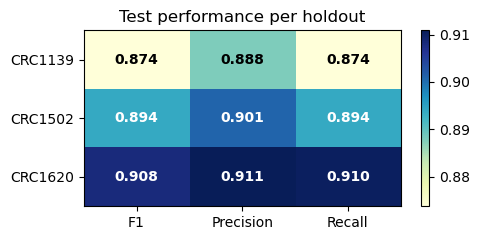

In [140]:
import numpy as np
import matplotlib.pyplot as plt

cols = [ "F1_weighted", "P_weighted", "R_weighted"]
M = df_folds.set_index("holdout")[cols].astype(float)

rename_dict = {
    "F1_weighted": "F1",
    "P_weighted": "Precision",
    "R_weighted": "Recall"
}

df_plot = df_folds.rename(columns=rename_dict)

cols = [ "F1", "Precision", "Recall"]

M = df_plot.set_index("holdout")[cols].astype(float)

fig, ax = plt.subplots(figsize=(5, max(2.5, 0.45 * len(M))))
im = ax.imshow(M.values, aspect="auto",cmap="YlGnBu" )

ax.set_xticks(np.arange(M.shape[1]))
ax.set_xticklabels(cols, rotation=0)
ax.set_yticks(np.arange(M.shape[0]))
ax.set_yticklabels(M.index)

vmin = M.values.min()
vmax = M.values.max()
threshold = (vmin + vmax) / 2.0  # punto medio per cambiare colore

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        value = M.values[i, j]
        color = "white" if value > threshold else "black"
        ax.text(j, i, f"{value:.3f}",
                ha="center", va="center",
                color=color, fontsize=10, fontweight="bold")

ax.set_title("Test performance per holdout")
plt.colorbar(im, ax=ax)
plt.tight_layout()
im.set_rasterized(True)
fig.savefig("test_performance_f1.pdf",dpi=300)
plt.show()

In [141]:
scaler_final = MaxAbsScaler()
X_kras_scaled = scaler_final.fit_transform(X)

rf_final = RandomForestClassifier(**rf_params)
rf_final.fit(X_kras_scaled, y)

print("RF trained on all KRAS. tau_final =", tau_final)

RF trained on all KRAS. tau_final = 0.07666666666666669


In [142]:
test=pd.DataFrame()

In [143]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat_gae/'
dataset='SMC'
tipo=['T']
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    tipo_=str.split(sample_name,sep='-')[1]
    if dataset in sample_name and tipo_ in tipo:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=tipo_
        data.reset_index(drop=True,inplace=True)
        test=pd.concat([test,data])

filtered_annotated_saver_ribomito_SMC01-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC02-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC03-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC04-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC06-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC07-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC08-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC09-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC10-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC11-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC14-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC15-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC16-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC17-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC18-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC19-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_SMC20-T_log2_pc1_cpm.c

In [144]:
from func_NT_cetux import *
dt=test
df_clean_dt, dup = strip_prefix_from_genes(dt, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")
df_clean_dt = df_clean_dt.reindex(columns=to_keep, fill_value=0)
df_clean_dt = df_clean_dt.loc[:,to_keep]
df_clean_dt['uid']=df_clean_dt['sample']+df_clean_dt['trattamento']+'|'+df_clean_dt['cell_id']+'|'+df_clean_dt['trattamento']
df_clean_dt.head()
df_clean_dt.index=df_clean_dt['uid']
meta_cols_dt = ['uid','sample','cell_id','trattamento']
feature_cols = [c for c in df_clean_dt.columns if c not in meta_cols_dt]
X_dt = df_clean_dt[feature_cols].copy()
X_dt_scaled = scaler_final.transform(X_dt)

In [145]:
import numpy as np
import pandas as pd

def margin_score(probs):
    p_sorted = np.sort(probs, axis=1)
    return p_sorted[:, -1] - p_sorted[:, -2]

# 1) probabilità WT
probs_dt = rf_final.predict_proba(X_dt_scaled)   
pred_dt  = probs_dt.argmax(axis=1)

# 2) score confidenza
maxprob_dt = probs_dt.max(axis=1)
margin_dt  = margin_score(probs_dt)

# 3) filtro con tau_final (calibrata sui KRAS)
accepted_dt = margin_dt >= tau_final

pred_dt_filt = pred_dt.copy()
pred_dt_filt[~accepted_dt] = -1   # -1 = Unknown

print("WT coverage (accepted):", accepted_dt.mean())
print("WT unknown:", (~accepted_dt).mean())


WT coverage (accepted): 0.6040420705300061
WT unknown: 0.3959579294699938


In [146]:

wt_pred_df = pd.DataFrame({
    "uid": df_clean_dt["uid"].values if "uid" in df_clean_dt.columns else df_clean_dt.index.values,
    "sample": df_clean_dt["sample"].values,
    "cell_id": df_clean_dt["cell_id"].values,
    "trattamento": df_clean_dt["trattamento"].values,
    "pred_cluster": pred_dt,
    "pred_cluster_filt": pred_dt_filt,
    "accepted": accepted_dt,
    "margin": margin_dt,
    "max_prob": maxprob_dt
}).set_index("uid")

print(wt_pred_df.head())
#path_to_save='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/Others_data/SMC_prediction.csv'


                                      sample                   cell_id  \
uid                                                                      
SMC01-TT|SMC01.T_AAACCTGCATACGCCG|T  SMC01-T  SMC01.T_AAACCTGCATACGCCG   
SMC01-TT|SMC01.T_AAACCTGGTCGCATAT|T  SMC01-T  SMC01.T_AAACCTGGTCGCATAT   
SMC01-TT|SMC01.T_AAACCTGTCCCTTGCA|T  SMC01-T  SMC01.T_AAACCTGTCCCTTGCA   
SMC01-TT|SMC01.T_AAACGGGAGGGAAACA|T  SMC01-T  SMC01.T_AAACGGGAGGGAAACA   
SMC01-TT|SMC01.T_AAACGGGGTATAGGTA|T  SMC01-T  SMC01.T_AAACGGGGTATAGGTA   

                                    trattamento  pred_cluster  \
uid                                                             
SMC01-TT|SMC01.T_AAACCTGCATACGCCG|T           T             5   
SMC01-TT|SMC01.T_AAACCTGGTCGCATAT|T           T             0   
SMC01-TT|SMC01.T_AAACCTGTCCCTTGCA|T           T             3   
SMC01-TT|SMC01.T_AAACGGGAGGGAAACA|T           T             0   
SMC01-TT|SMC01.T_AAACGGGGTATAGGTA|T           T             1   

                         

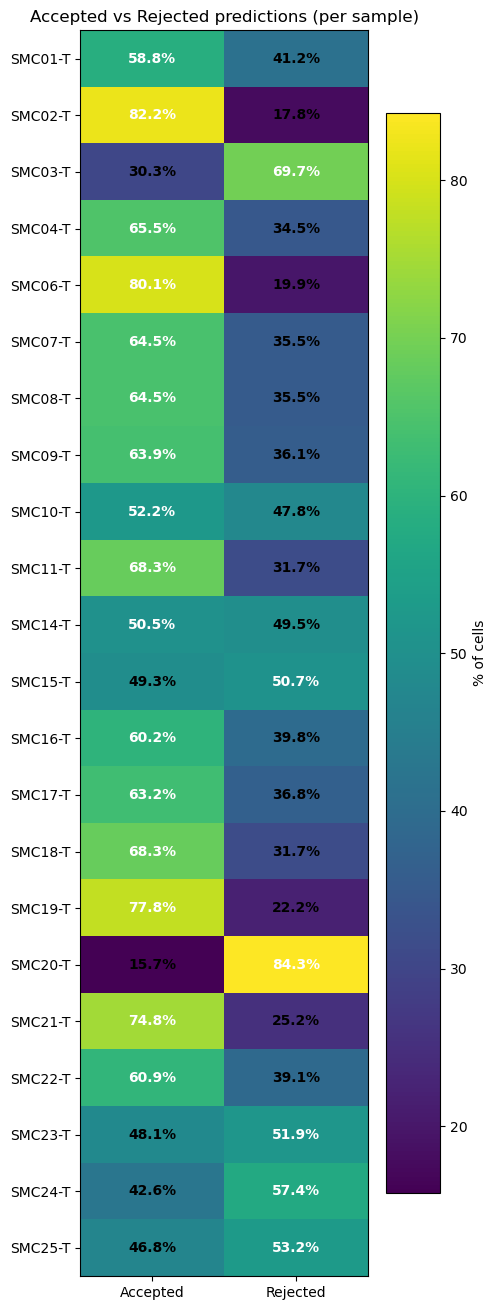

In [147]:
df = wt_pred_df.copy()

# =========================
# 1) Accepted vs Rejected per sample
# =========================

acc_sample = (
    df.groupby("sample")["accepted"]
      .value_counts(normalize=True)
      .rename("fraction")
      .mul(100)
      .reset_index()
)

# porto in tabella larga
acc_pivot = (
    acc_sample
    .pivot(index="sample", columns="accepted", values="fraction")
    .fillna(0)
)

# rinomino colonne in modo leggibile
acc_pivot = acc_pivot.rename(columns={True: "Accepted", False: "Rejected"})

# garantisco ordine colonne
for col in ["Accepted", "Rejected"]:
    if col not in acc_pivot.columns:
        acc_pivot[col] = 0
acc_pivot = acc_pivot[["Accepted", "Rejected"]]

fig, ax = plt.subplots(figsize=(5, max(4, 0.6 * len(acc_pivot))))

im = ax.imshow(acc_pivot.values, aspect="auto")

ax.set_xticks(range(acc_pivot.shape[1]))
ax.set_xticklabels(acc_pivot.columns)
ax.set_yticks(range(acc_pivot.shape[0]))
ax.set_yticklabels(acc_pivot.index)
ax.set_title("Accepted vs Rejected predictions (per sample)")

# testo dentro le celle
for i in range(acc_pivot.shape[0]):
    for j in range(acc_pivot.shape[1]):
        val = acc_pivot.iloc[i, j]
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                color="white" if val > 50 else "black", fontweight="bold")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% of cells")

plt.tight_layout()
plt.show()


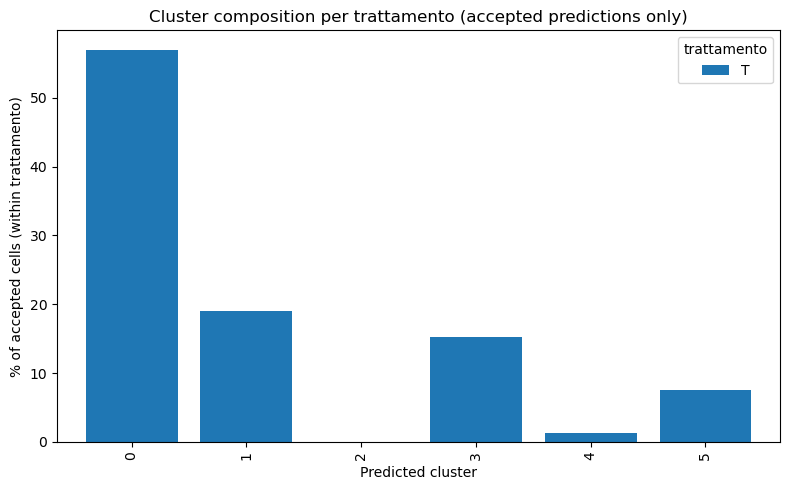

In [148]:
df_acc = df[df["accepted"]].copy()

# se vuoi usare il cluster filtrato:
cluster_col = "pred_cluster_filt"

# tolgo eventuali -1 residui
df_acc = df_acc[df_acc[cluster_col] >= 0]

comp_tratt = (
    df_acc.groupby("trattamento")[cluster_col]
          .value_counts(normalize=True)
          .rename("fraction")
          .mul(100)
          .reset_index()
)

comp_pivot = (
    comp_tratt
    .pivot(index=cluster_col, columns="trattamento", values="fraction")
    .fillna(0)
    .sort_index()
)

ax = comp_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster composition per trattamento (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("% of accepted cells (within trattamento)")
ax.legend(title="trattamento")
plt.tight_layout()
plt.show()

In [149]:
df_acc.head()

,sample,cell_id,trattamento,pred_cluster,pred_cluster_filt,accepted,margin,max_prob
uid,,,,,,,,
SMC01-TT|SMC01.T_AAACCTGGTCGCATAT|T,SMC01-T,SMC01.T_AAACCTGGTCGCATAT,T,0,0,True,0.133333,0.466667
SMC01-TT|SMC01.T_AAACCTGTCCCTTGCA|T,SMC01-T,SMC01.T_AAACCTGTCCCTTGCA,T,3,3,True,0.106667,0.330000
SMC01-TT|SMC01.T_AAACGGGAGGGAAACA|T,SMC01-T,SMC01.T_AAACGGGAGGGAAACA,T,0,0,True,0.116667,0.433333
SMC01-TT|SMC01.T_AAAGATGAGGCCGAAT|T,SMC01-T,SMC01.T_AAAGATGAGGCCGAAT,T,3,3,True,0.236667,0.423333
SMC01-TT|SMC01.T_AAAGATGCATGGATGG|T,SMC01-T,SMC01.T_AAAGATGCATGGATGG,T,3,3,True,0.100000,0.363333


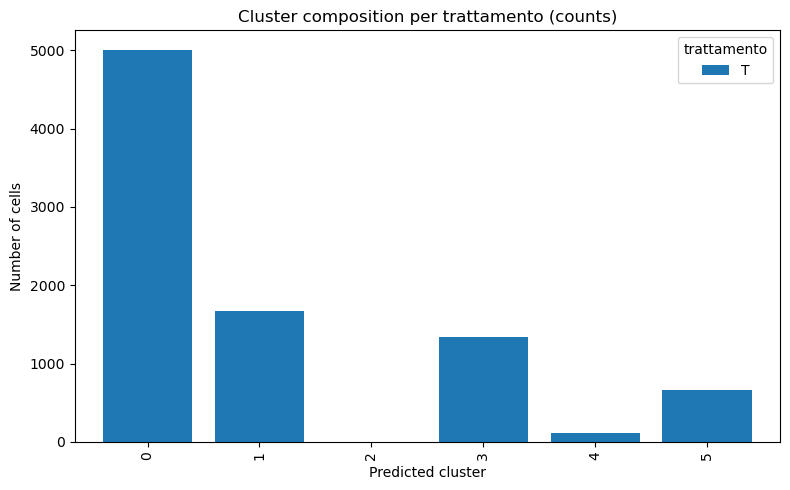

In [150]:
df_acc = df[df["accepted"]].copy()

cluster_col = "pred_cluster_filt"
df_acc = df_acc[df_acc[cluster_col] >= 0]

# conteggi assoluti
counts_tratt = (
    df_acc.groupby("trattamento")[cluster_col]
          .value_counts()
          .rename("count")
          .reset_index()
)

counts_pivot = (
    counts_tratt
    .pivot(index=cluster_col, columns="trattamento", values="count")
    .fillna(0)
    .sort_index()
)

ax = counts_pivot.plot(kind="bar", figsize=(8,5), width=0.8)
ax.set_title("Cluster composition per trattamento (counts)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("Number of cells")
ax.legend(title="trattamento")

plt.tight_layout()
plt.show()

genotype
wt      10587
kras     2522
NaN      1438
Name: count, dtype: int64


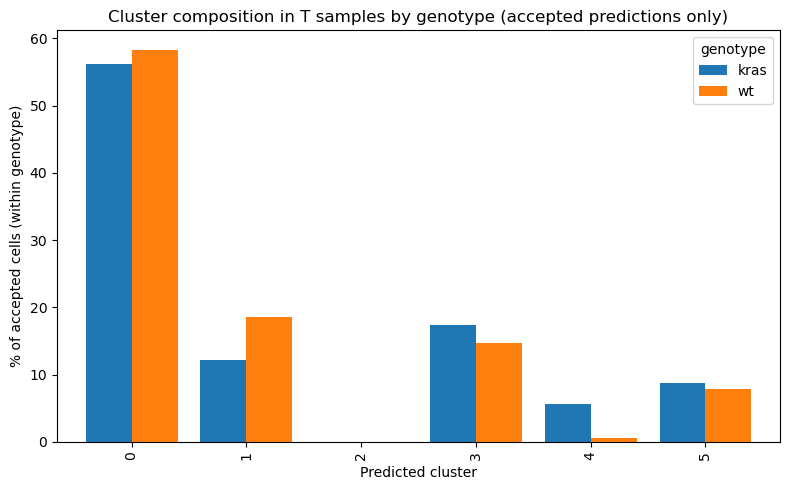

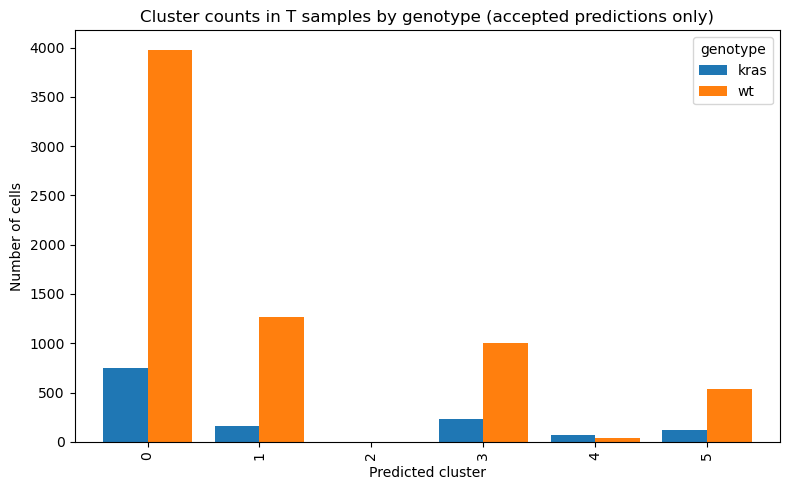

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) leggi samplesheet e costruisci mappa sample -> genotype
samplesheet = pd.read_csv("bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/Others_data/sample_sheet.csv")

sample_to_genotype = dict(zip(samplesheet["sample"], samplesheet["genotype"]))

# --- 2) copia df predizioni e tieni solo trattamento T
df = wt_pred_df.copy()
df = df[df["trattamento"] == "T"].copy()

# aggiungi genotype
df["genotype"] = df["sample"].map(sample_to_genotype)

# controllo rapido
print(df["genotype"].value_counts(dropna=False))

# opzionale: togli eventuali sample non matchati
df = df[df["genotype"].isin(["wt", "kras"])].copy()

# --- 3) tieni solo predizioni accettate
cluster_col = "pred_cluster_filt"
df_acc = df[df["accepted"]].copy()
df_acc = df_acc[df_acc[cluster_col] >= 0].copy()

# --- 4A) plot in percentuale per genotype
comp_geno_pct = (
    df_acc.groupby("genotype")[cluster_col]
          .value_counts(normalize=True)
          .rename("fraction")
          .mul(100)
          .reset_index()
)

comp_geno_pct_pivot = (
    comp_geno_pct
    .pivot(index=cluster_col, columns="genotype", values="fraction")
    .fillna(0)
    .sort_index()
)

ax = comp_geno_pct_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster composition in T samples by genotype (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("% of accepted cells (within genotype)")
ax.legend(title="genotype")
plt.tight_layout()
plt.show()

# --- 4B) plot in conteggi assoluti per genotype
comp_geno_count = (
    df_acc.groupby("genotype")[cluster_col]
          .value_counts()
          .rename("count")
          .reset_index()
)

comp_geno_count_pivot = (
    comp_geno_count
    .pivot(index=cluster_col, columns="genotype", values="count")
    .fillna(0)
    .sort_index()
)

ax = comp_geno_count_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster counts in T samples by genotype (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("Number of cells")
ax.legend(title="genotype")
plt.tight_layout()
plt.show()

In [101]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat_gae/'
dataset='KUL'
tipo=['T','C']
test=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    tipo_=str.split(sample_name,sep='-')[1]
    if dataset in sample_name and tipo_ in tipo:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=tipo_
        data.reset_index(drop=True,inplace=True)
        test=pd.concat([test,data])

filtered_annotated_saver_ribomito_KUL01-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_KUL19-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_KUL21-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_KUL28-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_KUL30-T_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_KUL31-T_log2_pc1_cpm.csv


In [106]:
from func_NT_cetux import *
dt=test
df_clean_dt, dup = strip_prefix_from_genes(dt, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")
df_clean_dt = df_clean_dt.reindex(columns=to_keep, fill_value=0)
df_clean_dt = df_clean_dt.loc[:,to_keep]
df_clean_dt['uid']=df_clean_dt['sample']+df_clean_dt['trattamento']+'|'+df_clean_dt['cell_id']+'|'+df_clean_dt['trattamento']
df_clean_dt.head()
df_clean_dt.index=df_clean_dt['uid']
meta_cols_dt = ['uid','sample','cell_id','trattamento']
feature_cols = [c for c in df_clean_dt.columns if c not in meta_cols_dt]
X_dt = df_clean_dt[feature_cols].copy()
X_dt_scaled = scaler_final.transform(X_dt)

In [107]:
import numpy as np
import pandas as pd

def margin_score(probs):
    p_sorted = np.sort(probs, axis=1)
    return p_sorted[:, -1] - p_sorted[:, -2]

# 1) probabilità WT
probs_dt = rf_final.predict_proba(X_dt_scaled)   
pred_dt  = probs_dt.argmax(axis=1)

# 2) score confidenza
maxprob_dt = probs_dt.max(axis=1)
margin_dt  = margin_score(probs_dt)

# 3) filtro con tau_final (calibrata sui KRAS)
accepted_dt = margin_dt >= tau_final

pred_dt_filt = pred_dt.copy()
pred_dt_filt[~accepted_dt] = -1   # -1 = Unknown

print("WT coverage (accepted):", accepted_dt.mean())
print("WT unknown:", (~accepted_dt).mean())

WT coverage (accepted): 0.3903654485049834
WT unknown: 0.6096345514950167


In [108]:

wt_pred_df = pd.DataFrame({
    "uid": df_clean_dt["uid"].values if "uid" in df_clean_dt.columns else df_clean_dt.index.values,
    "sample": df_clean_dt["sample"].values,
    "cell_id": df_clean_dt["cell_id"].values,
    "trattamento": df_clean_dt["trattamento"].values,
    "pred_cluster": pred_dt,
    "pred_cluster_filt": pred_dt_filt,
    "accepted": accepted_dt,
    "margin": margin_dt,
    "max_prob": maxprob_dt
}).set_index("uid")

print(wt_pred_df.head())
path_to_save='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/Others_data/SMC_prediction.csv'

                                      sample                   cell_id  \
uid                                                                      
KUL01-TT|KUL01.T_AAACCTGGTCTTTCAT|T  KUL01-T  KUL01.T_AAACCTGGTCTTTCAT   
KUL01-TT|KUL01.T_AAAGATGGTATAGGGC|T  KUL01-T  KUL01.T_AAAGATGGTATAGGGC   
KUL01-TT|KUL01.T_AAAGATGGTGGCCCTA|T  KUL01-T  KUL01.T_AAAGATGGTGGCCCTA   
KUL01-TT|KUL01.T_AAAGCAAGTAAACACA|T  KUL01-T  KUL01.T_AAAGCAAGTAAACACA   
KUL01-TT|KUL01.T_AAAGCAATCACATGCA|T  KUL01-T  KUL01.T_AAAGCAATCACATGCA   

                                    trattamento  pred_cluster  \
uid                                                             
KUL01-TT|KUL01.T_AAACCTGGTCTTTCAT|T           T             0   
KUL01-TT|KUL01.T_AAAGATGGTATAGGGC|T           T             0   
KUL01-TT|KUL01.T_AAAGATGGTGGCCCTA|T           T             0   
KUL01-TT|KUL01.T_AAAGCAAGTAAACACA|T           T             0   
KUL01-TT|KUL01.T_AAAGCAATCACATGCA|T           T             3   

                         

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) leggi samplesheet e costruisci mappa sample -> genotype
samplesheet = pd.read_csv("bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/Others_data/sample_sheet.csv")

sample_to_genotype = dict(zip(samplesheet["sample"], samplesheet["genotype"]))

# --- 2) copia df predizioni e tieni solo trattamento T
df = wt_pred_df.copy()
df = df[df["trattamento"] == "T"].copy()

# aggiungi genotype
df["genotype"] = df["sample"].map(sample_to_genotype)

# controllo rapido
print(df["genotype"].value_counts(dropna=False))

# opzionale: togli eventuali sample non matchati
df = df[df["genotype"].isin(["wt", "kras"])].copy()

# --- 3) tieni solo predizioni accettate
cluster_col = "pred_cluster_filt"
df_acc = df[df["accepted"]].copy()
df_acc = df_acc[df_acc[cluster_col] >= 0].copy()

# --- 4A) plot in percentuale per genotype
comp_geno_pct = (
    df_acc.groupby("genotype")[cluster_col]
          .value_counts(normalize=True)
          .rename("fraction")
          .mul(100)
          .reset_index()
)

comp_geno_pct_pivot = (
    comp_geno_pct
    .pivot(index=cluster_col, columns="genotype", values="fraction")
    .fillna(0)
    .sort_index()
)

ax = comp_geno_pct_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster composition in T samples by genotype (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("% of accepted cells (within genotype)")
ax.legend(title="genotype")
plt.tight_layout()
plt.show()

# --- 4B) plot in conteggi assoluti per genotype
comp_geno_count = (
    df_acc.groupby("genotype")[cluster_col]
          .value_counts()
          .rename("count")
          .reset_index()
)

comp_geno_count_pivot = (
    comp_geno_count
    .pivot(index=cluster_col, columns="genotype", values="count")
    .fillna(0)
    .sort_index()
)

ax = comp_geno_count_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster counts in T samples by genotype (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("Number of cells")
ax.legend(title="genotype")
plt.tight_layout()
plt.show()

genotype
NaN    1204
Name: count, dtype: int64


TypeError: no numeric data to plot

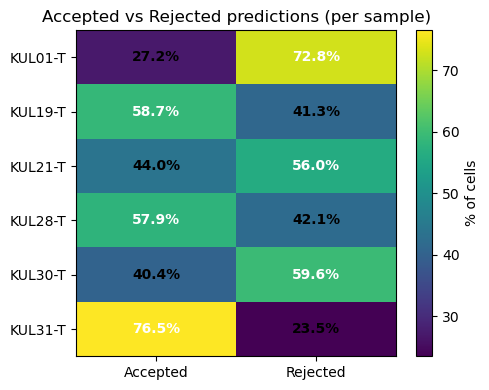

In [109]:
df = wt_pred_df.copy()

# =========================
# 1) Accepted vs Rejected per sample
# =========================

acc_sample = (
    df.groupby("sample")["accepted"]
      .value_counts(normalize=True)
      .rename("fraction")
      .mul(100)
      .reset_index()
)

# porto in tabella larga
acc_pivot = (
    acc_sample
    .pivot(index="sample", columns="accepted", values="fraction")
    .fillna(0)
)

# rinomino colonne in modo leggibile
acc_pivot = acc_pivot.rename(columns={True: "Accepted", False: "Rejected"})

# garantisco ordine colonne
for col in ["Accepted", "Rejected"]:
    if col not in acc_pivot.columns:
        acc_pivot[col] = 0
acc_pivot = acc_pivot[["Accepted", "Rejected"]]

fig, ax = plt.subplots(figsize=(5, max(4, 0.6 * len(acc_pivot))))

im = ax.imshow(acc_pivot.values, aspect="auto")

ax.set_xticks(range(acc_pivot.shape[1]))
ax.set_xticklabels(acc_pivot.columns)
ax.set_yticks(range(acc_pivot.shape[0]))
ax.set_yticklabels(acc_pivot.index)
ax.set_title("Accepted vs Rejected predictions (per sample)")

# testo dentro le celle
for i in range(acc_pivot.shape[0]):
    for j in range(acc_pivot.shape[1]):
        val = acc_pivot.iloc[i, j]
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                color="white" if val > 50 else "black", fontweight="bold")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% of cells")

plt.tight_layout()
plt.show()

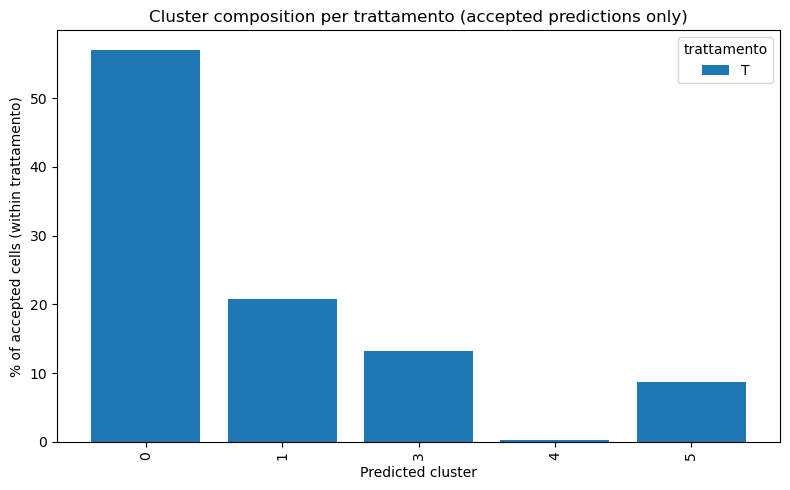

In [110]:
df_acc = df[df["accepted"]].copy()

# se vuoi usare il cluster filtrato:
cluster_col = "pred_cluster_filt"

# tolgo eventuali -1 residui
df_acc = df_acc[df_acc[cluster_col] >= 0]

comp_tratt = (
    df_acc.groupby("trattamento")[cluster_col]
          .value_counts(normalize=True)
          .rename("fraction")
          .mul(100)
          .reset_index()
)

comp_pivot = (
    comp_tratt
    .pivot(index=cluster_col, columns="trattamento", values="fraction")
    .fillna(0)
    .sort_index()
)

ax = comp_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster composition per trattamento (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("% of accepted cells (within trattamento)")
ax.legend(title="trattamento")
plt.tight_layout()
plt.show()

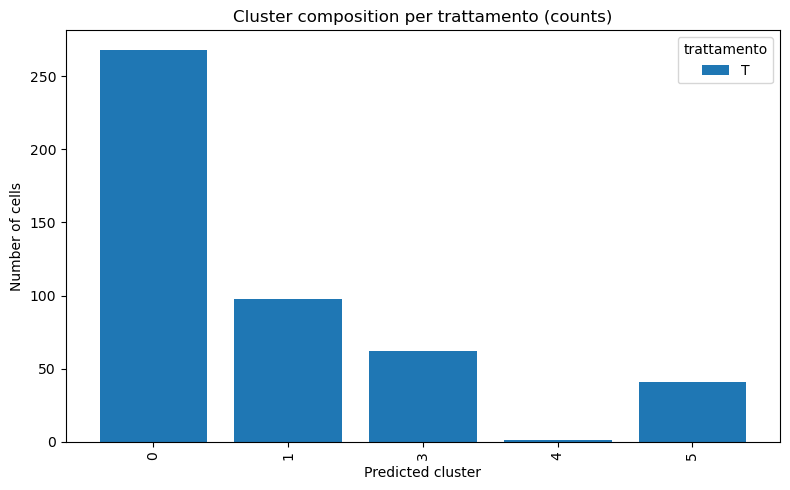

In [111]:
df_acc = df[df["accepted"]].copy()

cluster_col = "pred_cluster_filt"
df_acc = df_acc[df_acc[cluster_col] >= 0]

# conteggi assoluti
counts_tratt = (
    df_acc.groupby("trattamento")[cluster_col]
          .value_counts()
          .rename("count")
          .reset_index()
)

counts_pivot = (
    counts_tratt
    .pivot(index=cluster_col, columns="trattamento", values="count")
    .fillna(0)
    .sort_index()
)

ax = counts_pivot.plot(kind="bar", figsize=(8,5), width=0.8)
ax.set_title("Cluster composition per trattamento (counts)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("Number of cells")
ax.legend(title="trattamento")

plt.tight_layout()
plt.show()

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) leggi samplesheet e costruisci mappa sample -> genotype
samplesheet = pd.read_csv("bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/Others_data/sample_sheet.csv")

sample_to_genotype = dict(zip(samplesheet["sample"], samplesheet["genotype"]))

# --- 2) copia df predizioni e tieni solo trattamento T
df = wt_pred_df.copy()
df = df[df["trattamento"] == "T"].copy()

# aggiungi genotype
df["genotype"] = df["sample"].map(sample_to_genotype)

# controllo rapido
print(df["genotype"].value_counts(dropna=False))

# opzionale: togli eventuali sample non matchati
df = df[df["genotype"].isin(["wt", "kras"])].copy()

# --- 3) tieni solo predizioni accettate
cluster_col = "pred_cluster_filt"
df_acc = df[df["accepted"]].copy()
df_acc = df_acc[df_acc[cluster_col] >= 0].copy()

# --- 4A) plot in percentuale per genotype
comp_geno_pct = (
    df_acc.groupby("genotype")[cluster_col]
          .value_counts(normalize=True)
          .rename("fraction")
          .mul(100)
          .reset_index()
)

comp_geno_pct_pivot = (
    comp_geno_pct
    .pivot(index=cluster_col, columns="genotype", values="fraction")
    .fillna(0)
    .sort_index()
)

ax = comp_geno_pct_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster composition in T samples by genotype (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("% of accepted cells (within genotype)")
ax.legend(title="genotype")
plt.tight_layout()
plt.show()

# --- 4B) plot in conteggi assoluti per genotype
comp_geno_count = (
    df_acc.groupby("genotype")[cluster_col]
          .value_counts()
          .rename("count")
          .reset_index()
)

comp_geno_count_pivot = (
    comp_geno_count
    .pivot(index=cluster_col, columns="genotype", values="count")
    .fillna(0)
    .sort_index()
)

ax = comp_geno_count_pivot.plot(kind="bar", figsize=(8, 5), width=0.8)
ax.set_title("Cluster counts in T samples by genotype (accepted predictions only)")
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("Number of cells")
ax.legend(title="genotype")
plt.tight_layout()
plt.show()

genotype
NaN    1204
Name: count, dtype: int64


TypeError: no numeric data to plot